In [30]:
# Import the Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import re
import string
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Bidirectional, Embedding, Dense, Dropout, SpatialDropout1D )
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [31]:
# Load The Dataset
df=pd.read_csv(r"C:\Users\kumma\Downloads\IMDB DATASET\IMDB Dataset.csv")

In [32]:
# Basic information

print("\n Dataset Information:")
print("-" * 40)
print(f"  Shape of the dataset : {df.shape}")
print(f"  Total samples: {len(df)}")
print(f"  Number of columns: {len(df.columns)}")
print(f"  Column names: {list(df.columns)}")
print("-" * 40)



 Dataset Information:
----------------------------------------
  Shape of the dataset : (50000, 2)
  Total samples: 50000
  Number of columns: 2
  Column names: ['review', 'sentiment']
----------------------------------------


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [34]:
# Check for missing values
print("Missing Values Check:")
print("-" * 25)
print(df.isnull().sum())
print("-" * 25)

Missing Values Check:
-------------------------
review       0
sentiment    0
dtype: int64
-------------------------


In [35]:
# Sentiment distribution
print(" Sentiment Distribution:")
print("-" * 30)
sentiment_counts = df['sentiment'].value_counts(normalize=True)
print(sentiment_counts)
print("-" * 30)

 Sentiment Distribution:
------------------------------
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64
------------------------------


In [36]:
print("\n Review Length")
print("-" * 50)
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
df.head(5)


 Review Length
--------------------------------------------------


,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


In [37]:
# Review length statistics
print("\n Review Length Statistics:")
print("-" * 40)
print(df.describe())

print(f"\nAverage length: {df['review_length'].mean():.2f} words")
print(f"Minimum length: {df['review_length'].min()} words")
print(f"Maximum length: {df['review_length'].max()} words")
print(f"Median length: {df['review_length'].median():.2f} words")
print("-" * 40)


 Review Length Statistics:
----------------------------------------
       review_length
count   50000.000000
mean      231.156940
std       171.343997
min         4.000000
25%       126.000000
50%       173.000000
75%       280.000000
max      2470.000000

Average length: 231.16 words
Minimum length: 4 words
Maximum length: 2470 words
Median length: 173.00 words
----------------------------------------


In [38]:
print("\n📊 KEY FINDINGS:")
print("-" * 50)
print(f"✓ Dataset contains {len(df)} reviews")
print(f"✓ Binary classification: Positive and Negative")
print(f"✓ Balanced dataset: {sentiment_counts['positive']} positive, {sentiment_counts['negative']} negative")
print(f"✓ Average review length: {df['review_length'].mean():.1f} words")
print(f"✓ No missing values found")
print("-" * 50)


📊 KEY FINDINGS:
--------------------------------------------------
✓ Dataset contains 50000 reviews
✓ Binary classification: Positive and Negative
✓ Balanced dataset: 0.5 positive, 0.5 negative
✓ Average review length: 231.2 words
✓ No missing values found
--------------------------------------------------


In [39]:
print(" Text Cleaning...")

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)  # Remove emails
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters & spaces
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = text.strip()
    return text
    
# Apply text cleaning
df['clean_review'] = df['review'].apply(clean_text).str.lower()

print(" Tokenization...")
def tokenize(text):
    return text.split()

df['final_tokens'] = df['clean_review'].apply(tokenize)
print("\n✓ Text cleaning completed!")
print("✓ Lowercasing completed!")
print("✓ Tokenization completed!")


 Text Cleaning...
 Tokenization...

✓ Text cleaning completed!
✓ Lowercasing completed!
✓ Tokenization completed!


In [40]:
df[["review_length","clean_review","final_tokens"]].head()

,review_length,clean_review,final_tokens
0,307,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,162,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,166,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,138,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,230,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [41]:
word_counts = Counter()

for tokens in df['final_tokens']:
    word_counts.update(tokens)

print(f"✓ Total unique words found: {len(word_counts):,}")

✓ Total unique words found: 214,379


In [42]:
# Create Vocabulary
MAX_VOCAB_SIZE = 20000

sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
sorted_words = sorted_words[:MAX_VOCAB_SIZE]

word_to_index = {word: idx + 2 for idx, (word, _) in enumerate(sorted_words)}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1
vocab_size = len(word_to_index)


print(f"✓ Vocabulary created: {vocab_size:,} words")


✓ Vocabulary created: 20,002 words


In [43]:
#  Convert to Sequences
def tokens_to_sequence(tokens, word_to_index):
    return [word_to_index.get(token, 1) for token in tokens]

df['sequence'] = df['final_tokens'].apply(lambda x: tokens_to_sequence(x, word_to_index))
sequence_lengths = df['sequence'].apply(len)

print(f"✓ Sequences created")


✓ Sequences created


In [44]:
# Padding
MAX_SEQUENCE_LENGTH = 100

def pad_sequence(seq, max_len):
    if len(seq) > max_len:
        return seq[:max_len]
    return seq + [0] * (max_len - len(seq))

df['padded_sequence'] = df['sequence'].apply(lambda x: pad_sequence(x, MAX_SEQUENCE_LENGTH))

print(f"✓ Padding completed (max length: {MAX_SEQUENCE_LENGTH})")

✓ Padding completed (max length: 100)


In [45]:
#  Label Encoding
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})
label_counts = df['label'].value_counts().sort_index()

print(f"✓ Labels encoded")

✓ Labels encoded


In [46]:
# Create Final Arrays
X = np.array(df['padded_sequence'].tolist())
y = np.array(df['label'].tolist())

print(f"\n✅ PREPROCESSING COMPLETE!")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Vocab size: {vocab_size:,} | Max length: {MAX_SEQUENCE_LENGTH}")


✅ PREPROCESSING COMPLETE!
X shape: (50000, 100), y shape: (50000,)
Vocab size: 20,002 | Max length: 100


In [47]:
df.sample(6)

,review,sentiment,review_length,clean_review,final_tokens,sequence,padded_sequence,label
19852,"Well, I had to sit down at the computer and wr...",negative,174,well i had to sit down at the computer and wri...,"[well, i, had, to, sit, down, at, the, compute...","[73, 10, 67, 6, 818, 185, 30, 2, 1277, 3, 876,...","[73, 10, 67, 6, 818, 185, 30, 2, 1277, 3, 876,...",0
14262,Hobgoblins....Hobgoblins....where do I begin?!...,negative,153,hobgoblinshobgoblinswhere do i beginthis film ...,"[hobgoblinshobgoblinswhere, do, i, beginthis, ...","[1, 80, 10, 1, 19, 389, 9599, 2, 903, 5, 1994,...","[1, 80, 10, 1, 19, 389, 9599, 2, 903, 5, 1994,...",0
44409,And obviously I didn't see it! <br /><br />But...,negative,169,and obviously i didnt see it but looking at th...,"[and, obviously, i, didnt, see, it, but, looki...","[3, 512, 10, 148, 64, 9, 18, 271, 30, 2, 180, ...","[3, 512, 10, 148, 64, 9, 18, 271, 30, 2, 180, ...",0
14956,"Out of any category, this is one demented and ...",positive,148,out of any category this is one demented and o...,"[out, of, any, category, this, is, one, dement...","[44, 5, 98, 2494, 11, 7, 28, 5272, 3, 126, 2, ...","[44, 5, 98, 2494, 11, 7, 28, 5272, 3, 126, 2, ...",1
27859,"""Ashes of Time"" was an audacious project but e...",negative,267,ashes of time was an audacious project but end...,"[ashes, of, time, was, an, audacious, project,...","[9351, 5, 59, 13, 33, 14439, 1119, 18, 1008, 5...","[9351, 5, 59, 13, 33, 14439, 1119, 18, 1008, 5...",0
26750,'Helen of Troy' follows the story of Helen and...,negative,173,helen of troy follows the story of helen and t...,"[helen, of, troy, follows, the, story, of, hel...","[2647, 5, 11386, 1064, 2, 66, 5, 2647, 3, 2, 9...","[2647, 5, 11386, 1064, 2, 66, 5, 2647, 3, 2, 9...",0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review           50000 non-null  object
 1   sentiment        50000 non-null  object
 2   review_length    50000 non-null  int64 
 3   clean_review     50000 non-null  object
 4   final_tokens     50000 non-null  object
 5   sequence         50000 non-null  object
 6   padded_sequence  50000 non-null  object
 7   label            50000 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 3.1+ MB


In [49]:
# Split: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)  # Keep same ratio of positive/negative in both sets)

print("   ✓ Data split completed!")
print(f"\n   Training set:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Positive samples: {np.sum(y_train == 1):,}")
print(f"   Negative samples: {np.sum(y_train == 0):,}")

print(f"\n   Validation set:")
print(f"   X_val: {X_val.shape}")
print(f"   y_val: {y_val.shape}")
print(f"   Positive samples: {np.sum(y_val == 1):,}")
print(f"   Negative samples: {np.sum(y_val == 0):,}")


   ✓ Data split completed!

   Training set:
   X_train: (40000, 100)
   y_train: (40000,)
   Positive samples: 20,000
   Negative samples: 20,000

   Validation set:
   X_val: (10000, 100)
   y_val: (10000,)
   Positive samples: 5,000
   Negative samples: 5,000


In [50]:
# Model Building 
model = Sequential([
    Embedding(vocab_size + 1, 100),
    SpatialDropout1D(0.3),

    Bidirectional(LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    )),

    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


In [51]:
# Compile the model

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)


In [52]:
# Training The Model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training completed!")
model.summary()


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.6978 - loss: 0.5625 - val_accuracy: 0.8207 - val_loss: 0.4045
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.8483 - loss: 0.3712 - val_accuracy: 0.8299 - val_loss: 0.3768
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.8799 - loss: 0.3115 - val_accuracy: 0.8259 - val_loss: 0.3805

✓ Training completed!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (64, 100, 100)              │       2,000,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ (64, 100, 100)              │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (64, 128)                   │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (64, 32)                    │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (64, 32)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (64, 1)                     │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,266,825 (23.91 MB)

 Trainable params: 2,088,941 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,177,884 (15.94 MB)

In [53]:
# EVALUATE OF MODEL

print("\nEvaluating model...")

# Predictions
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
y_pred_prob = model.predict(X_val, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Results
print(f"\n✓ Validation Loss: {val_loss:.4f}")
print(f"✓ Validation Accuracy: {val_accuracy*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"True Negatives: {cm[0,0]} | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]} | True Positives: {cm[1,1]}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Negative', 'Positive']))



Evaluating model...

✓ Validation Loss: 0.3768
✓ Validation Accuracy: 82.99%

Confusion Matrix:
[[4280  720]
 [ 981 4019]]
True Negatives: 4280 | False Positives: 720
False Negatives: 981 | True Positives: 4019

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.86      0.83      5000
    Positive       0.85      0.80      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000




Creating confusion matrix plot...


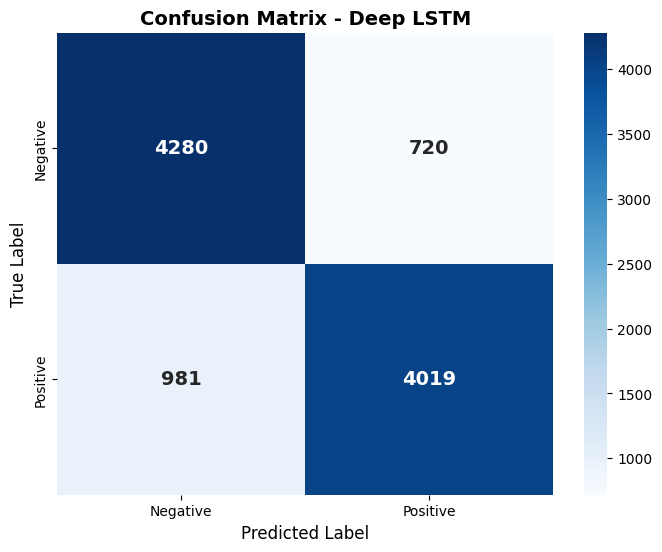

In [54]:
#  PLOTING CONFUSION MATRIX

print("\nCreating confusion matrix plot...")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - Deep LSTM', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()


Creating training plots...


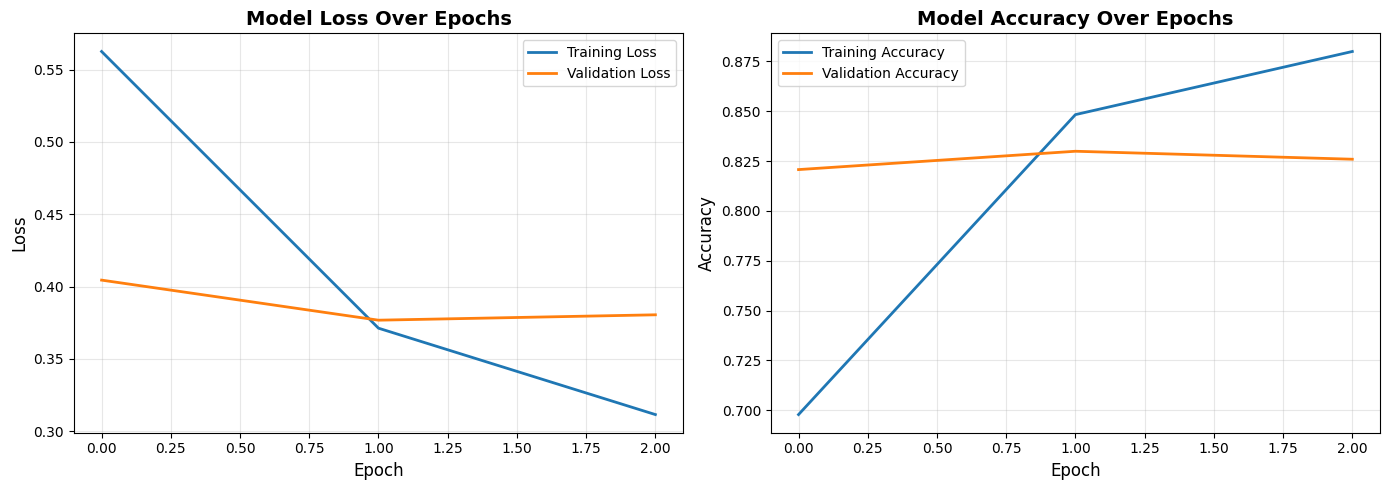

In [55]:
#  PLOTING TRAINING HISTORY

print("\nCreating training plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()